# 1. Eigenvalues and eigenvectors

Some vectors change length but keep their line of direction when a matrix transforms them. You will identify these special directions by hand, derive a two-by-two characteristic equation, implement its essential calculation, and verify library results without depending on arbitrary signs. Prerequisites: [matrix multiplication](../../../02_Mathematics_for_ML/10_matrix_multiplication.ipynb), [rank](../../../02_Mathematics_for_ML/13_rank.ipynb), and [norms](../../../02_Mathematics_for_ML/14_norms_and_distances.ipynb). Our matrices and coordinates are dimensionless. Later PCA uses related mathematics, but this lesson does not fit a PCA model.

## 2. What problem does this solve?

A transformation can mix coordinates so thoroughly that its behavior is hard to see entry by entry. Finding directions that it merely stretches can reveal a simpler description. For example, a symmetric mixing of two sensor channels may stretch their common movement strongly while stretching their disagreement weakly. Those directions help explain how the transformation acts on arbitrary inputs, and why repeated applications emphasize some patterns more than others.

## 3. Intuition and analogy

Imagine drawing arrows on an elastic sheet and stretching it. Most arrows turn as well as lengthen. An arrow along a principal stretch direction stays on the same line. An eigenvector describes such a line. Its eigenvalue tells us the factor by which the arrow changes. A negative factor reverses the arrow along its line; a zero factor collapses it to the origin. The special vector must be nonzero because the zero vector provides no direction to explain.

## 4. Terminology

An eigenvector is a nonzero vector whose transformed version is a scalar multiple of itself. The corresponding scalar is its eigenvalue. Together they form an eigenpair. A unit vector has Euclidean norm one. Orthogonal vectors have zero dot product; orthonormal vectors are orthogonal and unit length. A real symmetric matrix equals its transpose. Such matrices have real eigenvalues and can be described using an orthonormal eigenvector basis. General real matrices need not have these properties.

## 5. Mathematical foundations

For \(A\) with shape \((n,n)\), eigenvector \(v\) of length \(n\), and scalar eigenvalue \(\lambda\),
\[
Av=\lambda v,\qquad v\ne0.
\]
The Greek letter lambda names the scaling factor. Rearranging gives \((A-\lambda I_n)v=0\), where \(I_n\) is the identity. A nonzero solution requires that this matrix be singular. Thus \(\det(A-\lambda I_n)=0\). For \(A=[[a,b],[c,d]]\), expanding the determinant gives
\[
\lambda^2-(a+d)\lambda+(ad-bc)=0.
\]
The trace \(a+d\) is the diagonal sum; \(ad-bc\) is the determinant. This quadratic gives eigenvalues, after which a corresponding nonzero vector is found by solving the remaining linear relation. All symbols here are scalars except the explicitly named matrix and vectors.

For a symmetric matrix with orthonormal eigenvectors as columns of \(Q\),
\[
A=Q\Lambda Q^T.
\]
Here \(Q\) has shape \((n,n)\), \(\Lambda\) is the diagonal matrix of eigenvalues, and \(Q^TQ=I_n\). Reading right to left: express a vector in the special coordinates, stretch each coordinate, then return to the original coordinates.

## 6. Hand-calculated example

Let \(A=[[2,1],[1,2]]\). The quadratic is \(\lambda^2-4\lambda+3=0=(\lambda-1)(\lambda-3)\), so eigenvalues are 1 and 3. For \(v=[1,1]\), multiplication gives [3,3]=3v. For \(w=[1,-1]\), multiplication gives [1,-1]=w. Their dot product is 1-1=0, and each norm is the square root of 2. Dividing each by that norm gives unit directions. An ordinary input [2,0] equals v+w, so its output is 3v+w=[4,2].

## 7. Essential scratch mechanism

We implement the characteristic quadratic for a real symmetric two-by-two matrix. Symmetry means the off-diagonal entries match. The discriminant becomes (a-d)^2+4b^2, always nonnegative. This direct formula can suffer cancellation for extreme entries, so use a library for demanding numerical work. It is not a general eigensolver. For our manual example we supply the eigenvectors derived above rather than pretending that the quadratic alone computes them.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import math
import numpy as np

def symmetric_two_eigenvalues(values):
    matrix = np.asarray(values, dtype=float)
    if matrix.shape != (2, 2) or not np.isfinite(matrix).all():
        raise ValueError('Use a finite 2 by 2 matrix.')
    if not np.array_equal(matrix, matrix.T):
        raise ValueError('This teaching formula requires exact symmetry.')
    a, b, _, d = matrix.ravel()
    root = math.sqrt((a-d)**2 + 4*b*b)
    return np.array([(a+d-root)/2, (a+d+root)/2])

A = np.array([[2., 1.], [1., 2.]])
eigenvalues = symmetric_two_eigenvalues(A)
Q = np.array([[1., 1.], [-1., 1.]]) / np.sqrt(2)
assert np.allclose(eigenvalues, [1, 3])
assert np.allclose(Q.T @ Q, np.eye(2))
assert np.allclose(A @ Q, Q * eigenvalues)
print('Hand-derived eigenvalues:', eigenvalues)

Hand-derived eigenvalues: [1. 3.]


## 8. Output inspection

Columns of Q correspond to eigenvalues in the same order. Broadcasting `Q * eigenvalues` multiplies each column by its matching scalar. A reconstruction check catches mismatched ordering. Changing a vector's sign preserves its eigenpair equation, so comparing raw coordinates to one expected signed vector is unnecessarily restrictive.

In [3]:
for index in range(2):
    vector = Q[:, index]
    print('Direction, transformed direction, eigenvalue:',
          vector, A @ vector, eigenvalues[index])
assert np.allclose(Q @ np.diag(eigenvalues) @ Q.T, A)
ordinary = np.array([2., 0.])
coordinates = Q.T @ ordinary
reconstructed_output = Q @ (eigenvalues * coordinates)
assert np.allclose(reconstructed_output, [4, 2])
print('Input coordinates in eigenvector basis:', coordinates)

Direction, transformed direction, eigenvalue: [ 0.70710678 -0.70710678] [ 0.70710678 -0.70710678] 1.0
Direction, transformed direction, eigenvalue: [0.70710678 0.70710678] [2.12132034 2.12132034] 3.0
Input coordinates in eigenvector basis: [1.41421356 1.41421356]


## 9. Library implementation

`np.linalg.eigh` is designed for real symmetric matrices and returns ascending eigenvalues with eigenvectors in columns. Use `eig` for a general square matrix; do not assume its vectors are orthogonal or its eigenvalues real. The rotation example below has no real direction that stays on its own line: a quarter turn moves every nonzero real arrow to a perpendicular direction. Complex numbers extend the algebra, but are not required for our symmetric examples.

In [4]:
values, vectors = np.linalg.eigh(A)
assert np.allclose(values, [1, 3])
assert np.allclose(A @ vectors, vectors * values)
assert np.allclose(vectors.T @ vectors, np.eye(2))
assert np.allclose(vectors @ np.diag(values) @ vectors.T, A)
rotation = np.array([[0., -1.], [1., 0.]])
rotation_values = np.linalg.eigvals(rotation)
assert np.allclose(np.abs(rotation_values.imag), 1)
print('Quarter-turn eigenvalues:', rotation_values)

Quarter-turn eigenvalues: [0.+1.j 0.-1.j]


## 10. Visualization

The plot draws unit eigenvectors and their transformed arrows, both from the origin. The direction associated with 3 grows threefold. The direction associated with 1 overlaps its transformed version because it is unchanged. An arbitrary arrow turns toward the more strongly stretched direction. Equal axis scaling is necessary to judge angles faithfully.

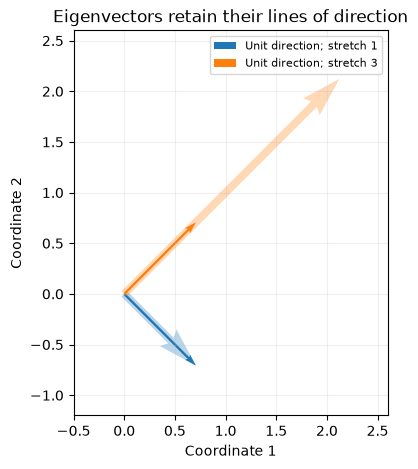

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(6, 5))
for index, color in enumerate(['tab:blue', 'tab:orange']):
    vector = Q[:, index]
    transformed = A @ vector
    ax.quiver(0, 0, *transformed, angles='xy', scale_units='xy', scale=1,
              color=color, alpha=.3, width=.025)
    ax.quiver(0, 0, *vector, angles='xy', scale_units='xy', scale=1,
              color=color, label=f'Unit direction; stretch {eigenvalues[index]:g}')
ax.set(xlim=(-.5, 2.6), ylim=(-1.2, 2.6), xlabel='Coordinate 1',
       ylabel='Coordinate 2', title='Eigenvectors retain their lines of direction')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(alpha=.2)
display(fig)
plt.close(fig)

## 11. Synthetic repeated-transformation experiment

Begin with [1,0], which contains both eigen-directions. Repeated mixing multiplies one component by 3 each time and leaves the other unchanged. We normalize after each step to keep magnitude bounded; normalization changes length but not direction. The normalized sequence approaches the dominant direction because its initial component in that direction is nonzero and 3 has the unique largest absolute eigenvalue. This is the central idea behind power iteration, not a universal convergence guarantee.

In [6]:
state = np.array([1., 0.])
for step in range(6):
    state = A @ state
    state /= np.linalg.norm(state)
    print('Step', step + 1, 'normalized coordinates:', state)
dominant = Q[:, 1]
assert abs(state @ dominant) > .999
negative = np.diag([-2., 1.])
assert np.allclose(negative @ [1, 0], [-2, 0])

Step 1 normalized coordinates: [0.89442719 0.4472136 ]
Step 2 normalized coordinates: [0.78086881 0.62469505]
Step 3 normalized coordinates: [0.73279349 0.6804511 ]
Step 4 normalized coordinates: [0.71578195 0.69832385]
Step 5 normalized coordinates: [0.71001067 0.70419091]
Step 6 normalized coordinates: [0.70807608 0.70613615]


## 12. Computational choices

There is no supervised training here. Matrix entries are supplied, and the eigenpairs describe that matrix. Iteration count and stopping tolerance would be computational choices for an iterative solver. Normalization prevents unchecked growth but does not solve all convergence problems. If a matrix is estimated from data, such as a covariance matrix, its eigenpairs also depend on estimation noise; that is separate from numerical eigensolver error.

## 13. Evaluation

For each eigenpair, inspect the residual Av-lambda*v. For symmetric problems check orthonormality and reconstruction as well. A tiny residual validates the algebra for the supplied matrix, not the quality of an underlying scientific model. Compare subspaces rather than individual vectors when eigenvalues repeat: several different orthonormal bases can describe the same eigenspace. In more demanding cases, scale residual checks to matrix and vector magnitudes.

## 14. Assumptions and limitations

Our hand derivation handles a symmetric two-by-two matrix. General real matrices may have complex eigenvalues, too few independent eigenvectors, or unstable eigenvector directions under small perturbations. Even symmetric matrices with nearly repeated eigenvalues can have sensitive individual directions. Eigenvalues are not automatically nonnegative; symmetry guarantees real values, not positivity. Covariance matrices have additional properties that this arbitrary example does not establish.

## 15. Mistakes and debugging

Do not call the zero vector an eigenvector. Do not multiply vector entries elementwise by a matrix when you intend Av. Keep eigenvalues paired with their corresponding columns. A sign difference from a textbook is not an error. Passing a nonsymmetric matrix to a symmetric solver can silently analyze only the triangle it uses; validate the mathematical assumptions instead of trusting a plausible output.

## 16. Alternatives and relationships

Rank counts independent directions but not their stretching factors. Eigenpairs describe square transformations that preserve selected lines. Singular-value decomposition works for rectangular matrices too and separates input directions from output directions, making it more general for data tables. PCA needs centering and a statistical interpretation beyond simply finding eigenvectors of an arbitrary matrix. Those distinctions prevent memorized formulas from becoming incorrect modeling recipes.

## 17. Exercises

1. **Beginner:** Verify that [1,-1] has eigenvalue 1 for A.
2. **Beginner:** Find eigenpairs of diag(2,5).
3. **Beginner:** Explain why -[1,1] is also an eigenvector of A.
4. **Intermediate:** Reconstruct A from Q and eigenvalues without using a library eigensolver.
5. **Intermediate:** Start repeated transformation exactly in the eigenvalue-1 direction. Does it approach the eigenvalue-3 direction?
6. **Challenge:** Explain why every nonzero vector is an eigenvector of 2I, and why a unique pair of preferred eigenvectors cannot be recovered.

## 18. Worked solutions

1. A[1,-1]=[2-1,1-2]=[1,-1], precisely one times the input.
2. Coordinate vectors [1,0] and [0,1] have eigenvalues 2 and 5. Their nonzero multiples work too.
3. Linearity gives A(-v)=-(Av)=-3v=3(-v). The eigenvalue is unchanged by reversing the vector.
4. The first outer product contributes one half of [[1,-1],[-1,1]]. The second contributes three halves of [[1,1],[1,1]]. Adding gives [[2,1],[1,2]]. An outer product multiplies every entry of one vector by every entry of the other.
5. No. Multiplication leaves that direction unchanged; no dominant component is present to amplify. Numerical rounding may eventually introduce one, but that is not exact mathematical convergence from the stated input.
6. Multiplying any vector by 2I doubles it. The repeated eigenvalue 2 has the whole plane as its eigenspace. Any orthonormal basis works, so a solver's chosen basis is one valid convention rather than a unique scientific result.

In [7]:
assert np.allclose(A @ [1, -1], [1, -1])
assert np.allclose(-A @ Q[:, 1], 3 * (-Q[:, 1]))
manual_reconstruction = sum(eigenvalues[i] * np.outer(Q[:, i], Q[:, i])
                            for i in range(2))
assert np.allclose(manual_reconstruction, A)
assert np.allclose(np.linalg.matrix_power(A, 4) @ [1, -1], [1, -1])
assert np.allclose((2*np.eye(2)) @ [3, -7], 2*np.array([3, -7]))

## 19. Knowledge check

**What does an eigenvalue measure?** The scaling factor along its eigenvector's line.

**Can an eigenvalue be zero?** Yes; the corresponding nonzero vector collapses to zero.

**Does symmetry imply positive eigenvalues?** No; it guarantees real eigenvalues and an orthonormal eigenbasis.

**Why are eigenvectors nonunique in sign?** Reversing a vector preserves the eigenpair equation.

**Can a rectangular table be passed directly to eig?** No; eigenpairs in this definition require a square transformation.

## 20. Interview preparation

**Why use eigh for symmetric matrices?** It uses the problem's structure and returns real eigenvalues with orthonormal vectors.

**How do you verify an eigenpair?** Check the residual Av-lambda*v, using an appropriate numerical tolerance.

**When can power iteration fail to find one direction?** Missing initial component, tied dominant magnitudes, and other violated convergence conditions can prevent that result.

**Why compare subspaces for repeated eigenvalues?** Individual basis vectors are not uniquely determined inside that eigenspace.

**Why is eigendecomposition not automatically PCA?** PCA also specifies centered data, a variance objective, and training-only estimation in predictive workflows.

## 21. Summary and next steps

Eigenvectors identify preserved lines of a square transformation, and eigenvalues specify their stretching factors. Verify equations and assumptions instead of memorizing vector signs. Continue to [Singular Value Decomposition](../../../02_Mathematics_for_ML/16_singular_value_decomposition.ipynb), which also handles rectangular tables.